# SHAP-Based Explainability Analysis

This notebook explains the predictions of the selected tuned XGBoost model using SHAP (SHapley Additive exPlanations).

The analysis includes:

- Loading the final tuned XGBoost model
- Reconstructing the exact test set
- Computing SHAP values on a reproducible test sample
- Global feature-importance analysis
- SHAP bar and beeswarm plots
- Aggregated importance at the original-variable level
- Dependence plots for the most influential numeric predictors
- Local explanations for high-risk, low-risk, true-positive, false-positive, and false-negative cases
- Comparison of individual predicted probabilities
- Saving SHAP values, tables, and figures

The purpose is to understand not only how well the model predicts Cesarean delivery, but also which features drive its predictions.

## 1. Import Libraries

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from scipy import sparse

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

## 2. Configure the Explainability Run

Computing SHAP values for the entire test set may require substantial memory. A reproducible sample is therefore used for global SHAP analysis.

Increase `SHAP_SAMPLE_SIZE` later if the notebook runs comfortably on your computer.

In [2]:
RANDOM_STATE = 42

# Recommended first run for a 16 GB RAM system
SHAP_SAMPLE_SIZE = 5000

# Number of features shown in global plots
MAX_DISPLAY_FEATURES = 20

# Number of top numeric features for dependence plots
TOP_NUMERIC_DEPENDENCE_PLOTS = 5

print("SHAP sample size:", SHAP_SAMPLE_SIZE)
print("Maximum displayed features:", MAX_DISPLAY_FEATURES)

SHAP sample size: 5000
Maximum displayed features: 20


## 3. Load the Dataset, Preprocessor, Final Model, and Split Information

The same processed dataset, fitted tree preprocessor, respondent-level split, transformed feature names, and tuned XGBoost model created in earlier notebooks are reused.

In [3]:
possible_data_paths = [
    Path("../data/processed/df_model_v1.parquet"),
    Path("data/processed/df_model_v1.parquet")
]

data_path = next(
    (path for path in possible_data_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "df_model_v1.parquet was not found."
    )

possible_artifact_paths = [
    Path("../artifacts"),
    Path("artifacts")
]

artifact_path = next(
    (path for path in possible_artifact_paths if path.exists()),
    None
)

if artifact_path is None:
    raise FileNotFoundError(
        "The artifacts folder was not found."
    )

model_path = (
    artifact_path
    / "tuned_models"
    / "tuned_xgboost.joblib"
)

if not model_path.exists():
    raise FileNotFoundError(
        "The tuned XGBoost model was not found. "
        "Run the hyperparameter-tuning notebook first."
    )

df_model = pd.read_parquet(data_path)

tree_preprocessor = joblib.load(
    artifact_path / "tree_preprocessor.joblib"
)

split_indices = pd.read_csv(
    artifact_path / "train_test_split_indices.csv"
)

transformed_feature_names = pd.read_csv(
    artifact_path / "transformed_feature_names.csv"
)["feature_name"].to_numpy()

xgboost_model = joblib.load(model_path)

print("Dataset shape:", df_model.shape)
print("Number of transformed features:", len(transformed_feature_names))
print("Model path:", model_path.resolve())

Dataset shape: (201311, 49)
Number of transformed features: 99
Model path: C:\IPD\IPD\artifacts\tuned_models\tuned_xgboost.joblib


## 4. Reconstruct Predictors, Target, and Respondent Groups

The same variable exclusions used in the preprocessing and modeling notebooks are applied.

In [4]:
candidate_excluded_columns = [
    "respondent_id",
    "birth_index",
    "cluster_number",
    "household_number",
    "respondent_line_number",
    "sample_weight",
    "primary_sampling_unit",
    "sample_stratum_v022",
    "sample_stratum_v023",
    "state",
    "district",
    "delivery_place_code",
    "survey_weight",
    "csection"
]

excluded_columns = [
    column
    for column in candidate_excluded_columns
    if column in df_model.columns
]

X = df_model.drop(columns=excluded_columns).copy()

y = pd.to_numeric(
    df_model["csection"],
    errors="raise"
).astype(int)

groups = df_model["respondent_id"].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Unique respondents:", groups.nunique())

Predictor shape: (201311, 36)
Target shape: (201311,)
Unique respondents: 158429


## 5. Define Feature Groups and Convert Data Types

The same scikit-learn-compatible conversion used in the earlier notebooks is applied.

In [5]:
numeric_features = [
    "maternal_age",
    "education_years",
    "wealth_index",
    "birth_order",
    "total_children_ever_born",
    "preceding_birth_interval",
    "age_at_first_birth",
    "bmi",
    "first_anc_timing",
    "anc_visits"
]

categorical_features = [
    "facility_type",
    "residence",
    "religion",
    "social_group",
    "twin_order"
]

binary_features = [
    "health_insurance",
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider",
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure",
    "convulsions_during_pregnancy",
    "swelling_during_pregnancy"
]


def create_sklearn_compatible_frame(data):
    converted = pd.DataFrame(index=data.index)

    for feature in numeric_features:
        converted[feature] = (
            pd.to_numeric(
                data[feature],
                errors="coerce"
            )
            .to_numpy(
                dtype=np.float64,
                na_value=np.nan
            )
        )

    for feature in categorical_features + binary_features:
        converted[feature] = (
            data[feature]
            .astype("string")
            .fillna("Missing")
            .to_numpy(dtype=str)
        )

    return converted[data.columns]


X = create_sklearn_compatible_frame(X)

display(X.dtypes.value_counts())

str        26
float64    10
Name: count, dtype: int64

## 6. Recreate the Held-Out Test Set

The exact respondent-level split used during model evaluation is restored.

In [6]:
if len(split_indices) != len(df_model):
    raise ValueError(
        "Saved split length does not match the dataset."
    )

split_indices = split_indices.sort_values(
    "row_index"
).reset_index(drop=True)

if not np.array_equal(
    split_indices["row_index"].to_numpy(),
    df_model.index.to_numpy()
):
    raise ValueError(
        "Saved split indices do not match the dataset."
    )

train_mask = split_indices["split"].eq("train").to_numpy()
test_mask = split_indices["split"].eq("test").to_numpy()

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

groups_train = groups.loc[train_mask].copy()
groups_test = groups.loc[test_mask].copy()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(
    "Respondent overlap:",
    len(set(groups_train).intersection(set(groups_test)))
)

Training shape: (161048, 36)
Test shape: (40263, 36)
Respondent overlap: 0


## 7. Transform the Test Set

The saved tree preprocessor is used because the final model is XGBoost.

In [7]:
X_test_transformed = tree_preprocessor.transform(
    X_test
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

if X_test_transformed.shape[1] != len(
    transformed_feature_names
):
    raise ValueError(
        "The transformed feature count does not match "
        "the saved feature-name count."
    )

Transformed test shape: (40263, 99)


## 8. Verify the Loaded Final Model

The tuned XGBoost model is evaluated again on the test set to confirm that the saved model reproduces the earlier results.

In [8]:
test_predictions = xgboost_model.predict(
    X_test_transformed
)

test_probabilities = xgboost_model.predict_proba(
    X_test_transformed
)[:, 1]

model_verification = pd.DataFrame(
    {
        "metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC",
            "PR-AUC"
        ],
        "value": [
            accuracy_score(
                y_test,
                test_predictions
            ),
            precision_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            recall_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            f1_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            roc_auc_score(
                y_test,
                test_probabilities
            ),
            average_precision_score(
                y_test,
                test_probabilities
            )
        ]
    }
)

display(model_verification.round(4))

,metric,value
0,Accuracy,0.7248
1,Precision,0.4313
2,Recall,0.7471
3,F1-score,0.5469
4,ROC-AUC,0.8033
5,PR-AUC,0.5330


## 9. Create a Reproducible SHAP Sample

A stratified sample is drawn from the held-out test set so that both delivery classes are represented.

SHAP values are computed only on unseen test observations.

In [9]:
sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test)
)

test_sampling_frame = pd.DataFrame(
    {
        "position": np.arange(len(y_test)),
        "target": y_test.to_numpy()
    }
)

sampled_positions = (
    test_sampling_frame
    .groupby(
        "target",
        group_keys=False
    )
    .apply(
        lambda group: group.sample(
            n=max(
                1,
                round(
                    sample_size
                    * len(group)
                    / len(test_sampling_frame)
                )
            ),
            random_state=RANDOM_STATE
        ),
        include_groups=False
    )["position"]
    .to_numpy()
)

# Correct any small rounding difference
if len(sampled_positions) > sample_size:
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_positions = rng.choice(
        sampled_positions,
        size=sample_size,
        replace=False
    )

elif len(sampled_positions) < sample_size:
    remaining_positions = np.setdiff1d(
        np.arange(len(y_test)),
        sampled_positions
    )

    rng = np.random.default_rng(RANDOM_STATE)

    additional_positions = rng.choice(
        remaining_positions,
        size=sample_size - len(sampled_positions),
        replace=False
    )

    sampled_positions = np.concatenate(
        [
            sampled_positions,
            additional_positions
        ]
    )

sampled_positions = np.sort(sampled_positions)

X_shap_raw = X_test.iloc[
    sampled_positions
].copy()

y_shap = y_test.iloc[
    sampled_positions
].copy()

X_shap_transformed = X_test_transformed[
    sampled_positions
]

print("SHAP sample shape:", X_shap_transformed.shape)

display(
    y_shap.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
    .rename("percent")
    .to_frame()
)

SHAP sample shape: (5000, 99)


,percent
csection,
0,77.78
1,22.22


## 10. Convert the SHAP Sample to a Dense DataFrame

The transformed feature matrix is converted into a labeled DataFrame for clearer SHAP outputs.

With 5,000 rows and 99 features, this should remain manageable on a 16 GB RAM system.

In [10]:
if sparse.issparse(X_shap_transformed):
    X_shap_dense = X_shap_transformed.toarray()
else:
    X_shap_dense = np.asarray(
        X_shap_transformed
    )

X_shap_df = pd.DataFrame(
    X_shap_dense,
    columns=transformed_feature_names,
    index=X_shap_raw.index
)

print("Dense SHAP dataframe shape:", X_shap_df.shape)
print(
    "Approximate memory use in MB:",
    round(
        X_shap_df.memory_usage(
            deep=True
        ).sum()
        / 1024**2,
        2
    )
)

display(X_shap_df.head())

Dense SHAP dataframe shape: (5000, 99)
Approximate memory use in MB: 3.81


,numeric__maternal_age,numeric__education_years,numeric__wealth_index,numeric__birth_order,numeric__total_children_ever_born,numeric__preceding_birth_interval,numeric__age_at_first_birth,numeric__bmi,numeric__first_anc_timing,numeric__anc_visits,...,binary__counselled_severe_abdominal_pain_Missing,binary__counselled_high_blood_pressure_0,binary__counselled_high_blood_pressure_1,binary__counselled_high_blood_pressure_Missing,binary__convulsions_during_pregnancy_0,binary__convulsions_during_pregnancy_1,binary__convulsions_during_pregnancy_Missing,binary__swelling_during_pregnancy_0,binary__swelling_during_pregnancy_1,binary__swelling_during_pregnancy_Missing
99,27.0,0.0,2.0,1.0,1.0,33.0,27.0,21.52,2.0,5.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
106,29.0,8.0,4.0,1.0,1.0,33.0,28.0,27.05,2.0,12.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
158,34.0,8.0,1.0,3.0,3.0,37.0,24.0,20.91,3.0,8.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
222,29.0,12.0,4.0,1.0,1.0,33.0,29.0,20.89,1.0,7.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
240,32.0,6.0,2.0,2.0,2.0,23.0,27.0,23.13,1.0,19.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 11. Create the SHAP Explainer and Compute SHAP Values

`TreeExplainer` is used because the selected model is XGBoost.

Positive SHAP values push the model toward predicting Cesarean delivery. Negative SHAP values push it toward predicting vaginal delivery.

In [11]:
explainer = shap.TreeExplainer(
    xgboost_model
)

shap_values = explainer(
    X_shap_df
)

print("SHAP values shape:", shap_values.values.shape)
print("Base value shape:", np.asarray(shap_values.base_values).shape)

SHAP values shape: (5000, 99)
Base value shape: (5000,)


## 12. Create Readable Feature Names

The preprocessing prefixes are removed to make plots and tables easier to interpret.

In [12]:
def make_feature_name_readable(feature_name):
    readable = feature_name

    for prefix in [
        "numeric__",
        "categorical__",
        "binary__"
    ]:
        readable = readable.replace(
            prefix,
            ""
        )

    readable = readable.replace(
        "missingindicator_",
        "missing_"
    )

    return readable


readable_feature_names = np.array(
    [
        make_feature_name_readable(name)
        for name in transformed_feature_names
    ]
)

X_shap_readable = X_shap_df.copy()
X_shap_readable.columns = readable_feature_names

shap_values_readable = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_shap_readable.to_numpy(),
    feature_names=readable_feature_names
)

## 13. Global SHAP Feature-Importance Table

Mean absolute SHAP values measure the average magnitude of each transformed feature's contribution across the test sample.

In [13]:
global_importance = pd.DataFrame(
    {
        "feature": readable_feature_names,
        "mean_absolute_shap": np.abs(
            shap_values_readable.values
        ).mean(axis=0)
    }
).sort_values(
    "mean_absolute_shap",
    ascending=False
).reset_index(drop=True)

display(
    global_importance.head(
        MAX_DISPLAY_FEATURES
    ).round(6)
)

,feature,mean_absolute_shap
0,facility_type_private,0.544573
1,total_children_ever_born,0.262413
2,bmi,0.245390
3,wealth_index,0.163607
4,age_at_first_birth,0.142156
5,education_years,0.135703
6,anc_visits,0.132765
7,facility_type_public,0.127536
8,anc_doctor_1,0.116206
9,social_group_2,0.067800


## 14. SHAP Global Bar Plot

The bar plot ranks features by their average absolute contribution to model predictions.

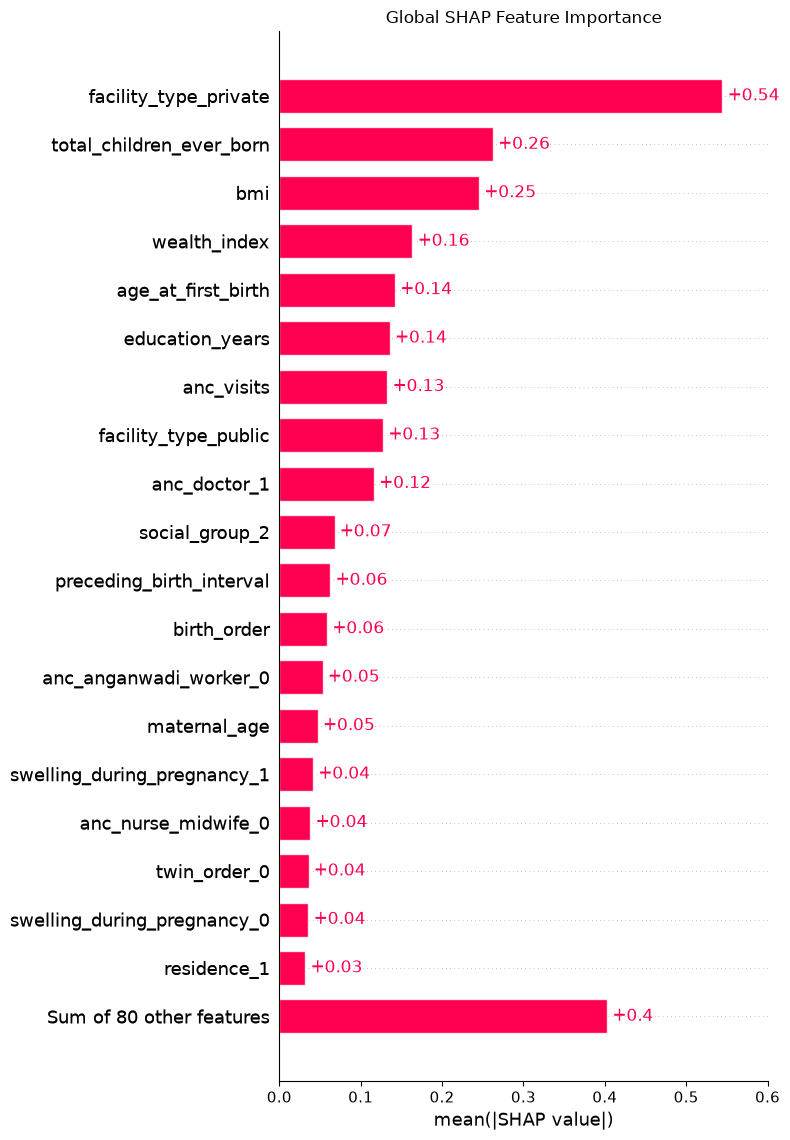

In [14]:
shap.plots.bar(
    shap_values_readable,
    max_display=MAX_DISPLAY_FEATURES,
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)
plt.tight_layout()
plt.show()

## 15. SHAP Beeswarm Plot

The beeswarm plot shows both feature importance and direction of effect:

- Points to the right increase the predicted Cesarean risk.
- Points to the left decrease the predicted Cesarean risk.
- Point color represents the feature value.

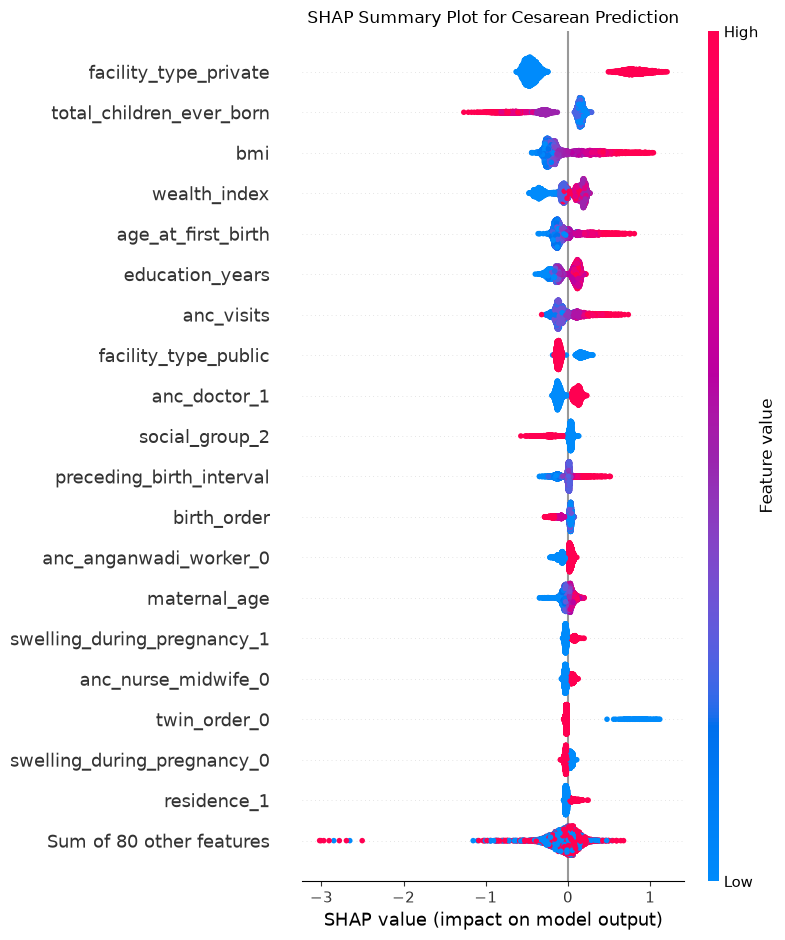

In [15]:
shap.plots.beeswarm(
    shap_values_readable,
    max_display=MAX_DISPLAY_FEATURES,
    show=False
)

plt.title(
    "SHAP Summary Plot for Cesarean Prediction"
)
plt.tight_layout()
plt.show()

## 16. Aggregate SHAP Importance to Original Variables

One-hot encoding expands one original variable into several transformed features. Their absolute SHAP contributions are summed so that importance can also be interpreted at the original-variable level.

In [16]:
def map_to_original_feature(
    transformed_name
):
    name = make_feature_name_readable(
        transformed_name
    )

    # Numeric variables and missing indicators
    for feature in numeric_features:
        if (
            name == feature
            or name == f"missing_{feature}"
        ):
            return feature

    # Categorical and binary one-hot columns
    for feature in (
        categorical_features
        + binary_features
    ):
        if name.startswith(
            f"{feature}_"
        ):
            return feature

    return name


transformed_to_original = {
    transformed_name: map_to_original_feature(
        transformed_name
    )
    for transformed_name
    in transformed_feature_names
}

aggregated_importance = (
    pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "original_feature": [
                transformed_to_original[name]
                for name
                in transformed_feature_names
            ],
            "mean_absolute_shap": np.abs(
                shap_values.values
            ).mean(axis=0)
        }
    )
    .groupby(
        "original_feature",
        as_index=False
    )["mean_absolute_shap"]
    .sum()
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    aggregated_importance.head(20).round(6)
)

,original_feature,mean_absolute_shap
0,facility_type,0.680196
1,total_children_ever_born,0.262413
2,bmi,0.249247
3,wealth_index,0.163607
4,age_at_first_birth,0.142156
5,anc_doctor,0.136787
6,education_years,0.135703
7,anc_visits,0.134337
8,social_group,0.100929
9,preceding_birth_interval,0.078568


## 17. Plot Aggregated Original-Variable Importance

This figure is easier to interpret in a report because each original predictor appears once.

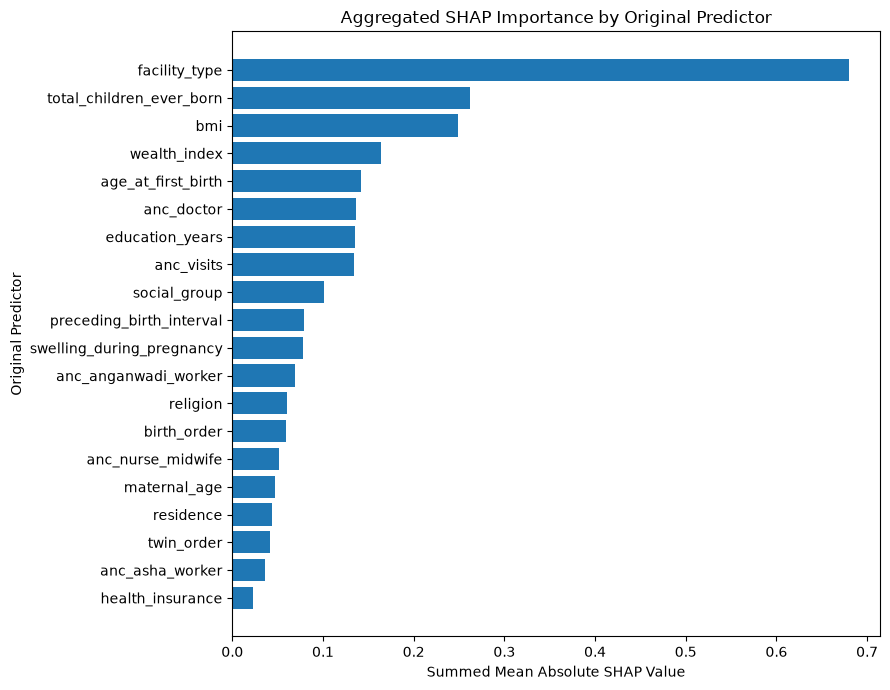

In [17]:
top_original_features = aggregated_importance.head(
    20
).sort_values(
    "mean_absolute_shap",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_original_features[
        "original_feature"
    ],
    top_original_features[
        "mean_absolute_shap"
    ]
)

plt.xlabel("Summed Mean Absolute SHAP Value")
plt.ylabel("Original Predictor")
plt.title(
    "Aggregated SHAP Importance by Original Predictor"
)
plt.tight_layout()
plt.show()

## 18. Identify the Most Important Numeric Features

Dependence plots are generated for the highest-ranked numeric predictors.

In [18]:
important_original_features = (
    aggregated_importance[
        "original_feature"
    ]
    .tolist()
)

top_numeric_features = [
    feature
    for feature in important_original_features
    if feature in numeric_features
][
    :TOP_NUMERIC_DEPENDENCE_PLOTS
]

print("Numeric features selected for dependence plots:")
print(top_numeric_features)

Numeric features selected for dependence plots:
['total_children_ever_born', 'bmi', 'wealth_index', 'age_at_first_birth', 'education_years']


## 19. SHAP Dependence Plots for Numeric Features

Each plot shows how the value of a numeric predictor relates to its SHAP contribution.

A positive SHAP value increases the predicted likelihood of Cesarean delivery, while a negative value decreases it.

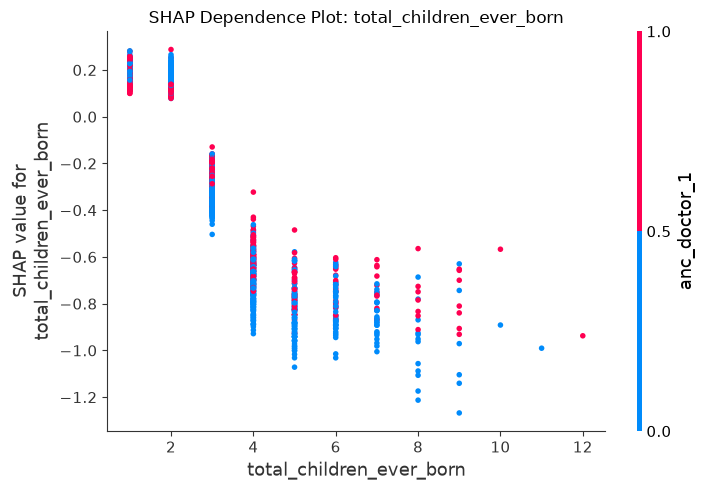

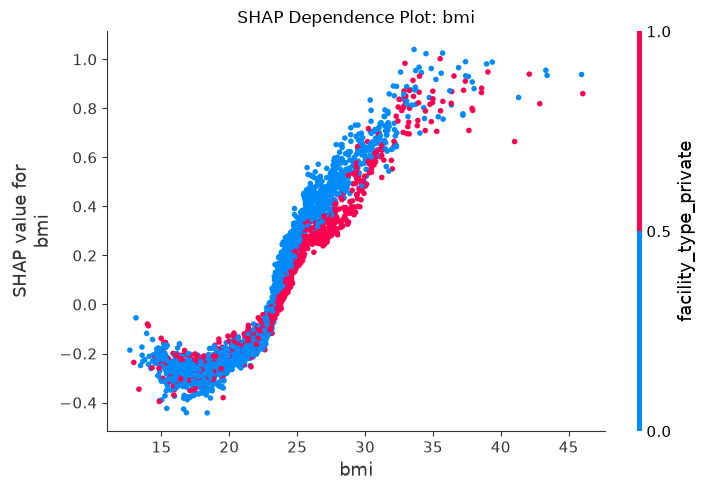

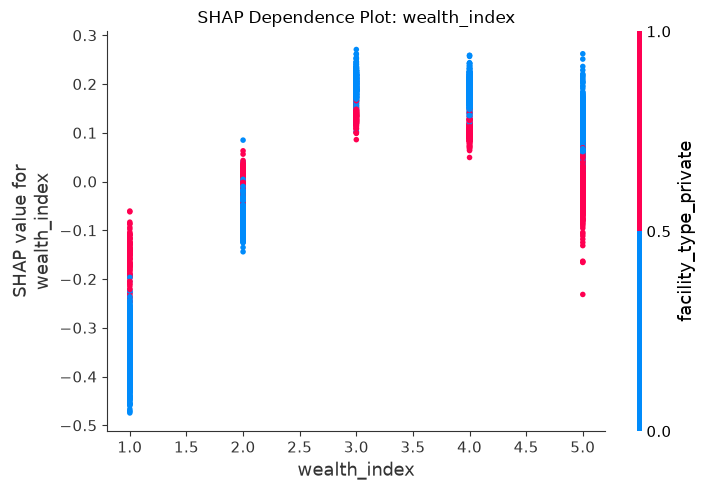

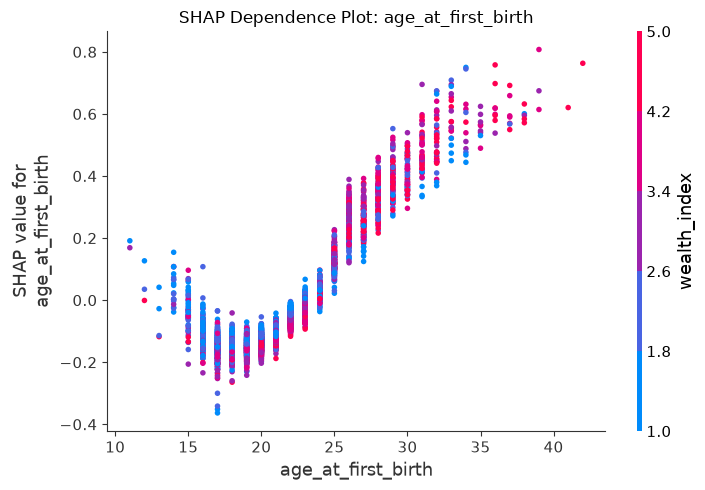

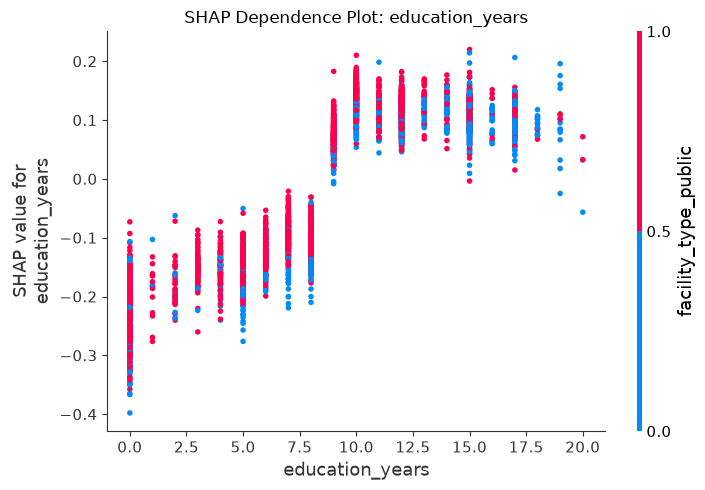

In [19]:
for feature in top_numeric_features:
    feature_index = list(
        readable_feature_names
    ).index(feature)

    shap.dependence_plot(
        ind=feature_index,
        shap_values=shap_values_readable.values,
        features=X_shap_readable,
        feature_names=readable_feature_names,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot: {feature}"
    )
    plt.tight_layout()
    plt.show()

## 20. Create a Prediction-Level Results Table

This table connects each sampled case's true outcome, predicted class, and predicted probability.

In [20]:
sample_probabilities = xgboost_model.predict_proba(
    X_shap_transformed
)[:, 1]

sample_predictions = (
    sample_probabilities >= 0.5
).astype(int)

prediction_explanations = pd.DataFrame(
    {
        "original_index": X_shap_raw.index,
        "actual_outcome": y_shap.to_numpy(),
        "predicted_class": sample_predictions,
        "predicted_probability": sample_probabilities
    }
).reset_index(drop=True)

prediction_explanations["prediction_type"] = np.select(
    [
        (
            prediction_explanations[
                "actual_outcome"
            ] == 1
        )
        & (
            prediction_explanations[
                "predicted_class"
            ] == 1
        ),
        (
            prediction_explanations[
                "actual_outcome"
            ] == 0
        )
        & (
            prediction_explanations[
                "predicted_class"
            ] == 0
        ),
        (
            prediction_explanations[
                "actual_outcome"
            ] == 0
        )
        & (
            prediction_explanations[
                "predicted_class"
            ] == 1
        ),
        (
            prediction_explanations[
                "actual_outcome"
            ] == 1
        )
        & (
            prediction_explanations[
                "predicted_class"
            ] == 0
        )
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

display(
    prediction_explanations.head()
)

,original_index,actual_outcome,predicted_class,predicted_probability,prediction_type
0,99,0,0,0.457871,True Negative
1,106,1,1,0.853214,True Positive
2,158,1,0,0.191586,False Negative
3,222,1,1,0.823572,True Positive
4,240,1,1,0.775613,True Positive


## 21. Select Representative Cases

Representative observations are selected for local explanation:

- Highest predicted risk
- Lowest predicted risk
- True positive
- False positive
- False negative

In [21]:
selected_case_positions = {
    "Highest predicted risk": int(
        prediction_explanations[
            "predicted_probability"
        ].idxmax()
    ),
    "Lowest predicted risk": int(
        prediction_explanations[
            "predicted_probability"
        ].idxmin()
    )
}

for case_type in [
    "True Positive",
    "False Positive",
    "False Negative"
]:
    matching_rows = prediction_explanations[
        prediction_explanations[
            "prediction_type"
        ] == case_type
    ]

    if not matching_rows.empty:
        if case_type == "True Positive":
            selected_position = int(
                matching_rows[
                    "predicted_probability"
                ].idxmax()
            )
        elif case_type == "False Positive":
            selected_position = int(
                matching_rows[
                    "predicted_probability"
                ].idxmax()
            )
        else:
            selected_position = int(
                matching_rows[
                    "predicted_probability"
                ].idxmin()
            )

        selected_case_positions[
            case_type
        ] = selected_position

selected_case_summary = pd.DataFrame(
    [
        {
            "case": case_name,
            **prediction_explanations.loc[
                position
            ].to_dict()
        }
        for case_name, position
        in selected_case_positions.items()
    ]
)

display(selected_case_summary)

,case,original_index,actual_outcome,predicted_class,predicted_probability,prediction_type
0,Highest predicted risk,173246,1,1,0.978445,True Positive
1,Lowest predicted risk,137669,0,0,0.010092,True Negative
2,True Positive,173246,1,1,0.978445,True Positive
3,False Positive,18940,0,1,0.929105,False Positive
4,False Negative,120795,1,0,0.059966,False Negative


## 22. Local SHAP Waterfall Plots

Each waterfall plot shows how individual features move the prediction from the model's baseline output toward a higher or lower Cesarean prediction.

Highest predicted risk


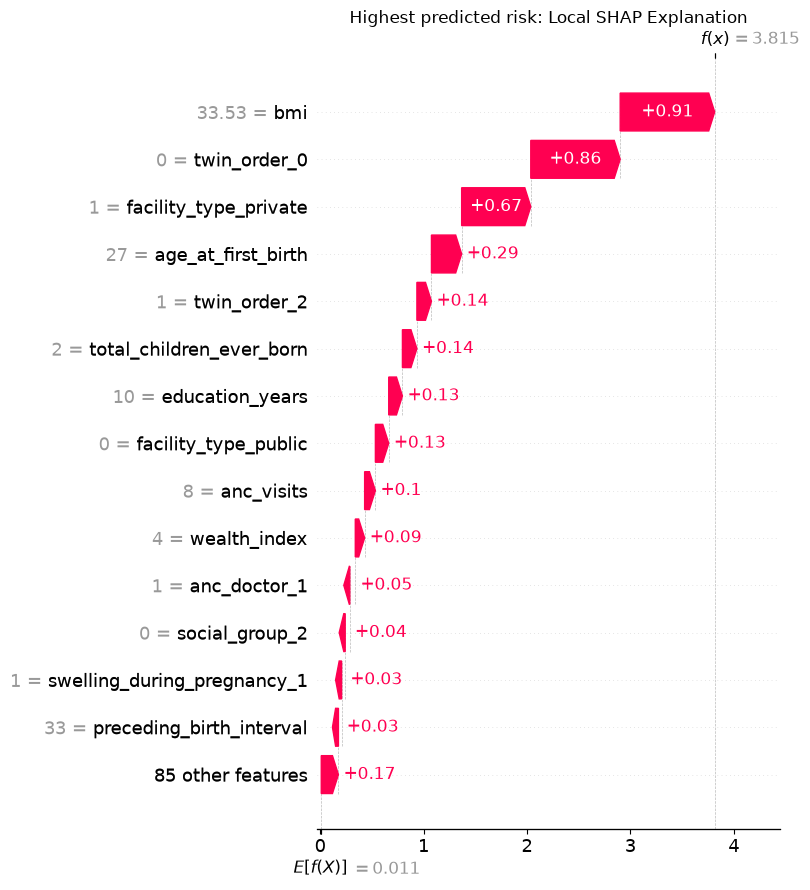

Lowest predicted risk


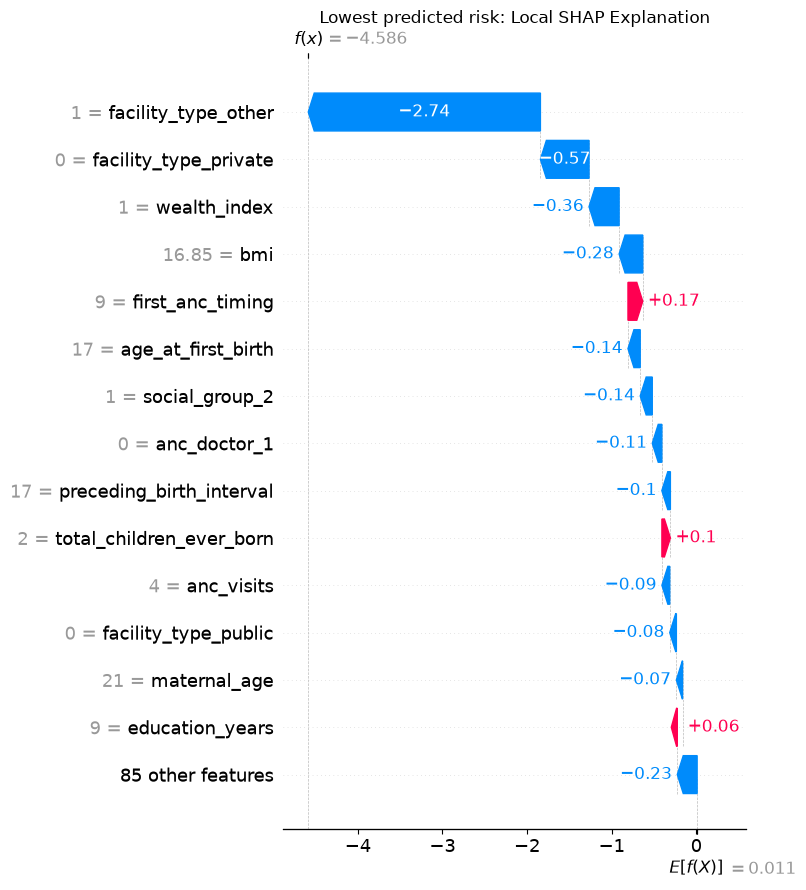

True Positive


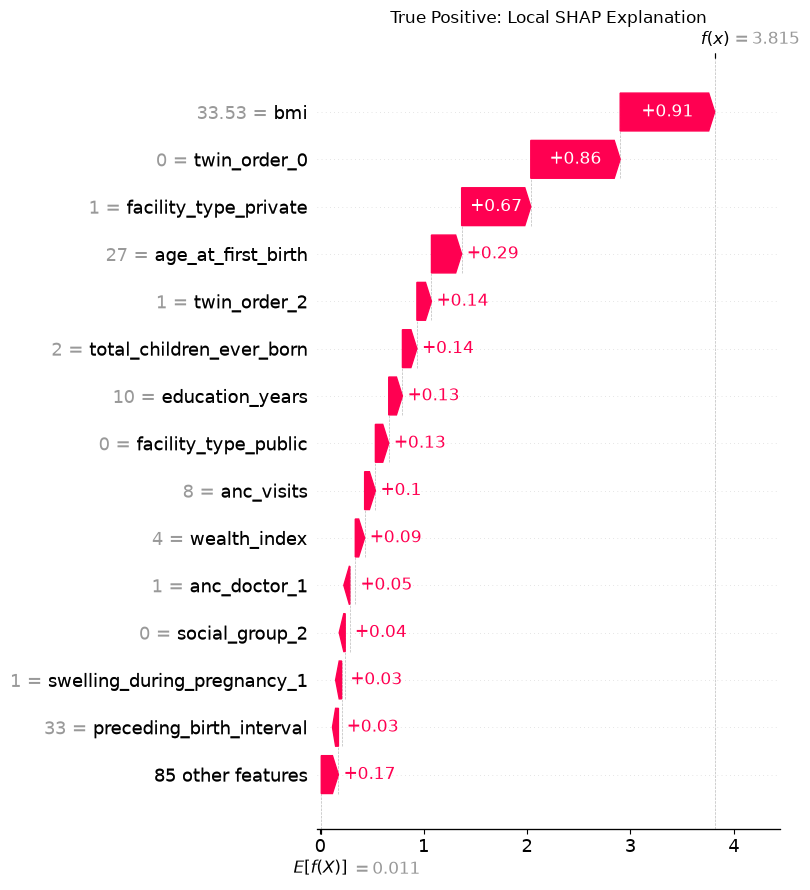

False Positive


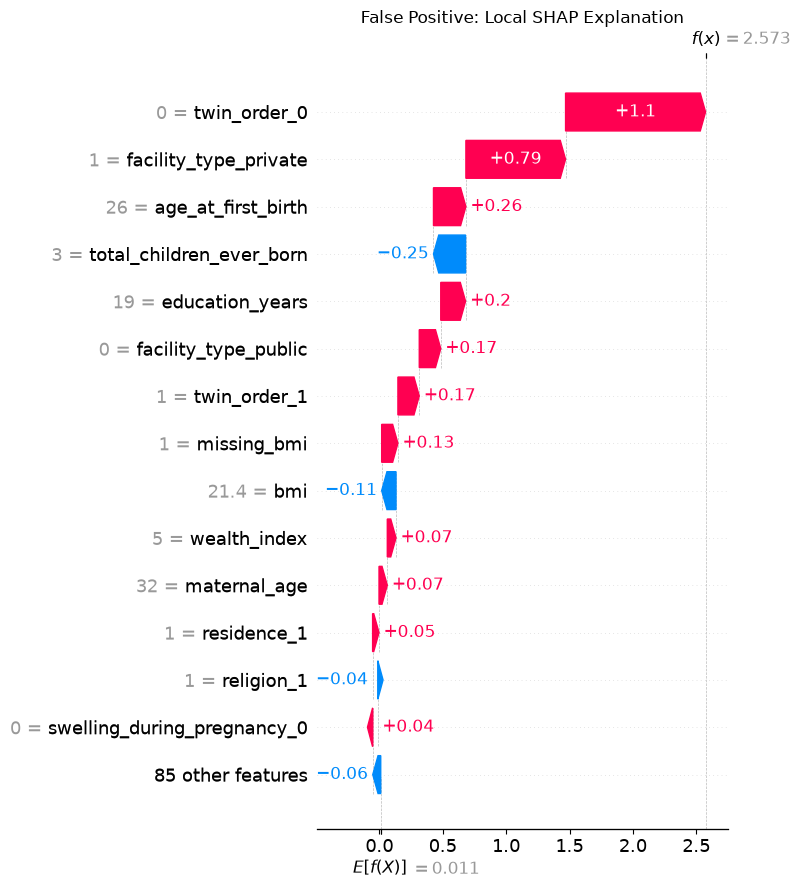

False Negative


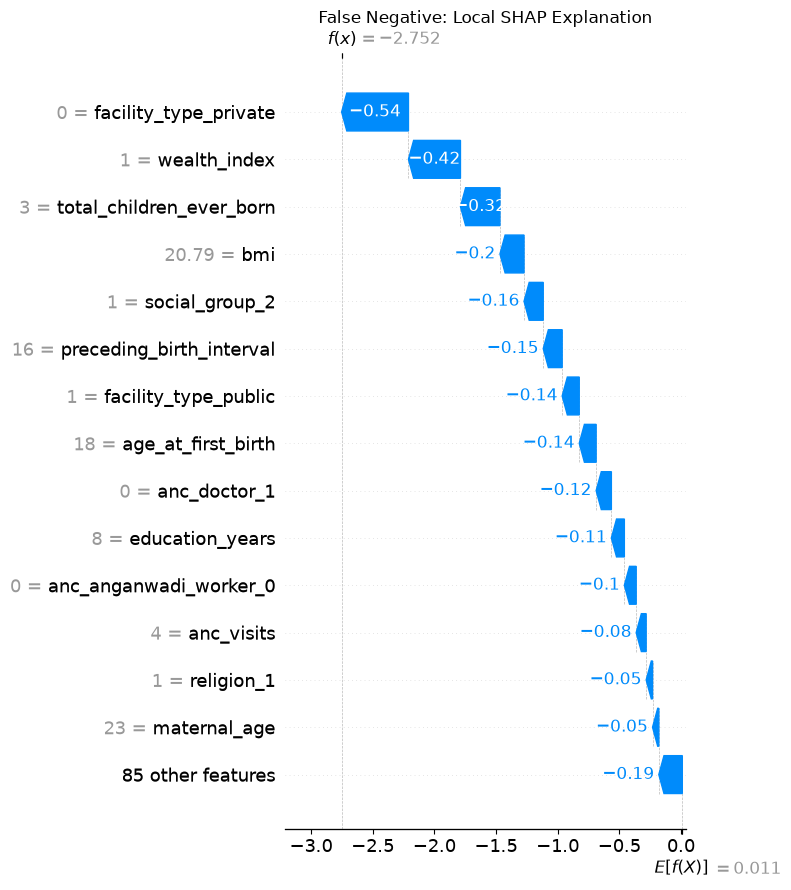

In [22]:
for case_name, position in selected_case_positions.items():
    print(case_name)

    shap.plots.waterfall(
        shap_values_readable[position],
        max_display=15,
        show=False
    )

    plt.title(
        f"{case_name}: Local SHAP Explanation"
    )
    plt.tight_layout()
    plt.show()

## 23. Local Feature-Contribution Tables

For each representative case, the strongest positive and negative SHAP contributions are displayed as a table.

In [23]:
local_contribution_tables = {}

for case_name, position in selected_case_positions.items():
    contribution_table = pd.DataFrame(
        {
            "feature": readable_feature_names,
            "feature_value": X_shap_readable.iloc[
                position
            ].to_numpy(),
            "shap_value": shap_values_readable.values[
                position
            ]
        }
    )

    contribution_table[
        "absolute_shap"
    ] = contribution_table[
        "shap_value"
    ].abs()

    contribution_table = contribution_table.sort_values(
        "absolute_shap",
        ascending=False
    )

    local_contribution_tables[
        case_name
    ] = contribution_table

    print(case_name)

    display(
        contribution_table.head(
            15
        ).drop(
            columns="absolute_shap"
        ).round(6)
    )

Highest predicted risk


,feature,feature_value,shap_value
7,bmi,33.53,0.913923
33,twin_order_0,0.00,0.864658
15,facility_type_private,1.00,0.668491
6,age_at_first_birth,27.00,0.292061
35,twin_order_2,1.00,0.140690
4,total_children_ever_born,2.00,0.140020
1,education_years,10.00,0.132474
16,facility_type_public,0.00,0.129016
9,anc_visits,8.00,0.103927
2,wealth_index,4.00,0.090405


Lowest predicted risk


,feature,feature_value,shap_value
14,facility_type_other,1.00,-2.743948
15,facility_type_private,0.00,-0.574791
2,wealth_index,1.00,-0.355566
7,bmi,16.85,-0.279392
8,first_anc_timing,9.00,0.174642
6,age_at_first_birth,17.00,-0.144675
29,social_group_2,1.00,-0.142469
40,anc_doctor_1,0.00,-0.113034
5,preceding_birth_interval,17.00,-0.101011
4,total_children_ever_born,2.00,0.100129


True Positive


,feature,feature_value,shap_value
7,bmi,33.53,0.913923
33,twin_order_0,0.00,0.864658
15,facility_type_private,1.00,0.668491
6,age_at_first_birth,27.00,0.292061
35,twin_order_2,1.00,0.140690
4,total_children_ever_born,2.00,0.140020
1,education_years,10.00,0.132474
16,facility_type_public,0.00,0.129016
9,anc_visits,8.00,0.103927
2,wealth_index,4.00,0.090405


False Positive


,feature,feature_value,shap_value
33,twin_order_0,0.0,1.104403
15,facility_type_private,1.0,0.786212
6,age_at_first_birth,26.0,0.255739
4,total_children_ever_born,3.0,-0.253261
1,education_years,19.0,0.195825
16,facility_type_public,0.0,0.169521
34,twin_order_1,1.0,0.168343
11,missing_bmi,1.0,0.128190
7,bmi,21.4,-0.113218
2,wealth_index,5.0,0.068798


False Negative


,feature,feature_value,shap_value
15,facility_type_private,0.00,-0.541864
2,wealth_index,1.00,-0.421697
4,total_children_ever_born,3.00,-0.320387
7,bmi,20.79,-0.195272
29,social_group_2,1.00,-0.155735
5,preceding_birth_interval,16.00,-0.153563
16,facility_type_public,1.00,-0.138419
6,age_at_first_birth,18.00,-0.137076
40,anc_doctor_1,0.00,-0.123467
1,education_years,8.00,-0.105342


## 24. Compare High-Risk and Low-Risk Cases

The strongest feature contributions for the highest-risk and lowest-risk sampled cases are placed side by side.

In [24]:
high_risk_position = selected_case_positions[
    "Highest predicted risk"
]

low_risk_position = selected_case_positions[
    "Lowest predicted risk"
]

high_risk_table = (
    local_contribution_tables[
        "Highest predicted risk"
    ]
    .head(10)
    .reset_index(drop=True)
    .add_prefix("high_risk_")
)

low_risk_table = (
    local_contribution_tables[
        "Lowest predicted risk"
    ]
    .head(10)
    .reset_index(drop=True)
    .add_prefix("low_risk_")
)

high_vs_low_comparison = pd.concat(
    [
        high_risk_table,
        low_risk_table
    ],
    axis=1
)

display(high_vs_low_comparison.round(6))

,high_risk_feature,high_risk_feature_value,high_risk_shap_value,high_risk_absolute_shap,low_risk_feature,low_risk_feature_value,low_risk_shap_value,low_risk_absolute_shap
0,bmi,33.53,0.913923,0.913923,facility_type_other,1.00,-2.743948,2.743948
1,twin_order_0,0.00,0.864658,0.864658,facility_type_private,0.00,-0.574791,0.574791
2,facility_type_private,1.00,0.668491,0.668491,wealth_index,1.00,-0.355566,0.355566
3,age_at_first_birth,27.00,0.292061,0.292061,bmi,16.85,-0.279392,0.279392
4,twin_order_2,1.00,0.140690,0.140690,first_anc_timing,9.00,0.174642,0.174642
5,total_children_ever_born,2.00,0.140020,0.140020,age_at_first_birth,17.00,-0.144675,0.144675
6,education_years,10.00,0.132474,0.132474,social_group_2,1.00,-0.142469,0.142469
7,facility_type_public,0.00,0.129016,0.129016,anc_doctor_1,0.00,-0.113034,0.113034
8,anc_visits,8.00,0.103927,0.103927,preceding_birth_interval,17.00,-0.101011,0.101011
9,wealth_index,4.00,0.090405,0.090405,total_children_ever_born,2.00,0.100129,0.100129


## 25. Save SHAP Tables, Values, and Figures

All key explainability outputs are saved for the report, paper, and future analysis.

In [25]:
shap_output_path = (
    artifact_path
    / "shap_explainability"
)

figure_output_path = (
    Path("../outputs/figures/shap")
    if Path("../outputs").parent.exists()
    else Path("outputs/figures/shap")
)

shap_output_path.mkdir(
    parents=True,
    exist_ok=True
)

figure_output_path.mkdir(
    parents=True,
    exist_ok=True
)

global_importance.to_csv(
    shap_output_path
    / "global_transformed_feature_importance.csv",
    index=False
)

aggregated_importance.to_csv(
    shap_output_path
    / "global_original_feature_importance.csv",
    index=False
)

prediction_explanations.to_csv(
    shap_output_path
    / "sample_prediction_explanations.csv",
    index=False
)

selected_case_summary.to_csv(
    shap_output_path
    / "selected_case_summary.csv",
    index=False
)

for case_name, contribution_table in local_contribution_tables.items():
    safe_name = (
        case_name
        .lower()
        .replace(" ", "_")
    )

    contribution_table.to_csv(
        shap_output_path
        / f"{safe_name}_contributions.csv",
        index=False
    )

np.save(
    shap_output_path / "shap_values.npy",
    shap_values_readable.values
)

np.save(
    shap_output_path / "shap_base_values.npy",
    np.asarray(
        shap_values_readable.base_values
    )
)

X_shap_readable.to_parquet(
    shap_output_path
    / "shap_sample_features.parquet"
)

print("SHAP artifacts saved at:")
print(shap_output_path.resolve())

SHAP artifacts saved at:
C:\IPD\IPD\artifacts\shap_explainability


### SHAP Explainability Summary

The SHAP analysis was performed using the final tuned XGBoost model to understand how individual predictors influenced Cesarean section predictions. Explanations were generated on a representative sample of 5,000 unseen test observations, ensuring that the interpretability analysis reflected the model's behavior on new data rather than the training set.

#### Most influential original predictors

The most influential predictors identified by the SHAP analysis were:

1. Facility type
2. Total children ever born
3. Body Mass Index (BMI)
4. Wealth index
5. Age at first birth
6. Doctor-provided antenatal care
7. Years of education
8. Number of ANC visits
9. Social group
10. Preceding birth interval

Among all variables, **facility type** had the highest overall importance, with deliveries in private facilities contributing strongly towards higher predicted Cesarean risk.

#### Features generally associated with higher Cesarean predictions

The SHAP analysis showed that higher predicted Cesarean probabilities were commonly associated with:

- Private health facility deliveries
- Higher maternal BMI
- Greater wealth index
- Older age at first birth
- Higher educational attainment
- Larger number of antenatal care visits
- Doctor-provided antenatal care
- Higher total number of children

These variables frequently produced positive SHAP values, indicating that they increased the model's predicted probability of Cesarean delivery.

#### Features generally associated with lower Cesarean predictions

Lower predicted Cesarean probabilities were generally associated with:

- Non-private facility deliveries
- Lower BMI
- Lower wealth index
- Younger age at first birth
- Fewer antenatal care visits
- Absence of doctor-provided ANC
- Shorter preceding birth interval in several cases

These variables generally produced negative SHAP values, reducing the predicted probability of Cesarean delivery.

#### Agreement with exploratory data analysis

The SHAP findings were broadly consistent with the earlier exploratory data analysis. Variables that demonstrated strong associations during EDA, particularly facility type, maternal BMI, socioeconomic status, and antenatal care utilization, also emerged as the most influential predictors in the machine learning model. This consistency increases confidence that the model learned meaningful patterns rather than relying on spurious relationships.

#### High-risk prediction characteristics

The highest-risk Cesarean predictions were typically driven by a combination of:

- Delivery in a private facility
- High maternal BMI
- Higher wealth index
- Greater number of ANC visits
- Older maternal and reproductive age
- Higher educational attainment

Rather than relying on a single predictor, the model combined multiple maternal, socioeconomic, and healthcare-related characteristics when assigning high Cesarean probabilities.

#### Low-risk prediction characteristics

Women with very low predicted Cesarean probabilities generally exhibited:

- Non-private facility deliveries
- Lower BMI
- Lower wealth index
- Younger age at first birth
- Fewer ANC visits
- Limited doctor-provided ANC

These characteristics collectively reduced the predicted probability of Cesarean delivery.

#### False-positive and false-negative predictions

The false-positive cases were typically women whose overall clinical and socioeconomic profiles closely resembled high-risk Cesarean cases despite having vaginal deliveries. Conversely, false-negative cases involved women who underwent Cesarean delivery but possessed characteristics generally associated with lower Cesarean risk, suggesting that important clinical factors not captured within the NFHS-5 dataset may also influence delivery mode.

#### Clinical interpretation

Overall, the SHAP explanations were clinically plausible. Maternal obesity, healthcare facility type, socioeconomic status, antenatal care utilization, and reproductive history are well-recognized factors associated with Cesarean delivery and were consistently identified by the model as important predictors.

It is important to note that SHAP explains **how the model makes its predictions** by identifying learned statistical associations. These explanations should **not** be interpreted as evidence that any individual factor directly causes Cesarean delivery.